<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Train_Dog%26Cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Mouneshgouda/Dog-and-Cat-Dataset.git

Cloning into 'Dog-and-Cat-Dataset'...
remote: Enumerating objects: 24999, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 24999 (delta 0), reused 0 (delta 0), pack-reused 24996 (from 1)
Receiving objects: 100% (24999/24999), 541.40 MiB | 28.69 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (24991/24991), done.


In [ ]:
train_path="/content/Dog-and-Cat-Dataset/data/train"
test_path="/content/Dog-and-Cat-Dataset/data/test"

In [ ]:
IMG_SIZE=64
BATCH_SIZE=32

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D

In [ ]:
from ast import Module
train=ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator=ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_path,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

model=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(IMG_SIZE,IMG_SIZE,3)),
    MaxPooling2D(2,2),
    Flatten(input_shape=(IMG_SIZE,IMG_SIZE,3)),
    Dense(128,activation="relu"),#hidden layer
    Dense(1,activation="sigmoid")#output layer
])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
model.fit(train,epochs=30)

Found 19989 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_n

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 170ms/step - accuracy: 0.6297 - loss: 0.6690
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.7671 - loss: 0.4850
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 162ms/step - accuracy: 0.7955 - loss: 0.4306
Epoch 4/10
314/625 ━━━━━━━━━━━━━━━━━━━━ 50s 163ms/step - accuracy: 0.8351 - loss: 0.3678

Now that the model is trained, let's evaluate its performance on the test dataset.

In [ ]:
from tensorflow.keras.preprocessing import image
import io
from PIL import Image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

Saving pexels-pixabay-45201.jpg to pexels-pixabay-45201 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


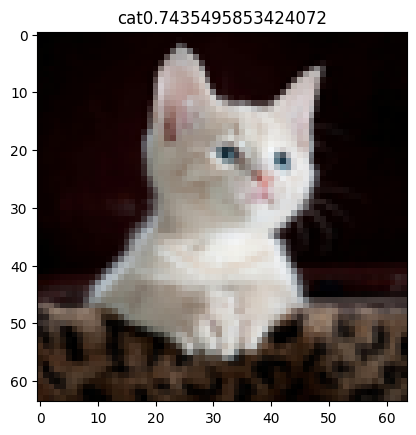

In [ ]:
uploaded=files.upload()

for filename in uploaded.keys():
  img=Image.open(filename).resize((IMG_SIZE,IMG_SIZE))
  img_ary=np.array(img)/255.0
  img_dim=np.expand_dims(img_ary,axis=0)
  prediction=model.predict(img_dim)[0][0]
  labels="Dog" if prediction>0.5 else "cat"
  confidence=prediction if prediction>0.5 else 1-prediction

  plt.imshow(img)
  plt.title(f"{labels}{confidence}")
